# Logistic regression (multy class)

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data

In [3]:
df = pd.read_csv('./data/iris.csv')

<Axes: >

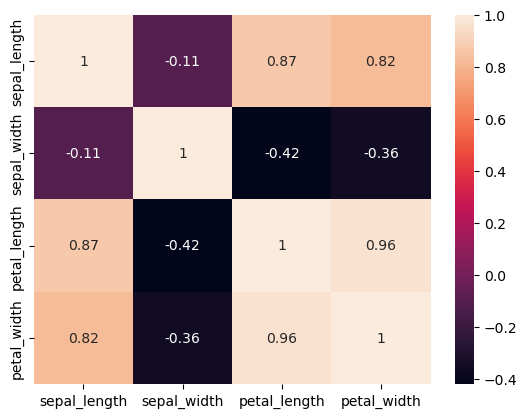

In [4]:
see_corr = df.drop('species', axis=1)
sns.heatmap(see_corr.corr(), annot=True)


In [5]:
# print(df['species'].value_counts())
# sns.countplot(x='species', data=df)
# sns.scatterplot(x='petal_length', y='petal_width', data=df, hue='species')
# sns.pairplot(df, hue='species')

## Split into on the features/target variable and training/testing data

In [6]:
X = df.drop('species', axis=1)
y = df['species']

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)
scaler =  StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

## Create model

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.multiclass import OneVsRestClassifier

In [10]:
# multi_class was deprecated in version 1.5 and will be removed in 1.7. 
# From then on, the recommended ‘multinomial’ will always be used for n_classes >= 3. 
# Solvers that do not support ‘multinomial’ will raise an error. 
# Use sklearn.multiclass.OneVsRestClassifier(LogisticRegression()) if you still want to use OvR.

'''
log_model = LogisticRegression(solver='saga', multi_class='ovr', max_iter=5000)
penalty = ['elasticnet'] # вариант: penalty = ['l1', 'l2', 'elasticnet']
l1_ratio = np.linspace(0, 1, 20)
C = np.logspace(0, 10, 20)
param_grid = {'penalty': penalty,
              'l1_ratio': l1_ratio,
              'C': C}
grid_model = GridSearchCV(log_model, param_grid=param_grid)
'''

"\nlog_model = LogisticRegression(solver='saga', multi_class='ovr', max_iter=5000)\npenalty = ['elasticnet'] # вариант: penalty = ['l1', 'l2', 'elasticnet']\nl1_ratio = np.linspace(0, 1, 20)\nC = np.logspace(0, 10, 20)\nparam_grid = {'penalty': penalty,\n              'l1_ratio': l1_ratio,\n              'C': C}\ngrid_model = GridSearchCV(log_model, param_grid=param_grid)\n"

In [11]:
log_model_raw = LogisticRegression(solver='saga', max_iter=5000)
log_model = OneVsRestClassifier(log_model_raw)

penalty = ['l2','elasticnet'] # вариант: penalty = ['l1', 'l2', 'elasticnet']
l1_ratio = np.linspace(0, 1, 10)
C = np.logspace(0, 10, 5)
param_grid = {'estimator__penalty': penalty,
              'estimator__l1_ratio': l1_ratio,
              'estimator__C': C
              }

# cv=5 - при кросс валидации данные будут разбиты на 5 частей
# n_jobs=-1 - будут задействованы все ядра процессора на машине
grid_model = GridSearchCV(estimator=log_model,  param_grid=param_grid, cv=5, n_jobs=-1)

## Learning model

In [12]:
grid_model.fit(scaled_X_train, y_train)

c:\Users\shaps\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\shaps\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\shaps\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


GridSearchCV(cv=5,
             estimator=OneVsRestClassifier(estimator=LogisticRegression(max_iter=5000,
                                                                        solver='saga')),
             n_jobs=-1,
             param_grid={'estimator__C': array([1.00000000e+00, 3.16227766e+02, 1.00000000e+05, 3.16227766e+07,
       1.00000000e+10]),
                         'estimator__l1_ratio': array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ]),
                         'estimator__penalty': ['l2', 'elasticnet']})

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [14]:
grid_model.best_params_

{'estimator__C': 316.22776601683796,
 'estimator__l1_ratio': 0.0,
 'estimator__penalty': 'l2'}

In [15]:
C[3:4]

array([31622776.60168379])

In [16]:
y_pred = grid_model.predict(scaled_X_test)

In [17]:
print(accuracy_score(y_test, y_pred))

0.9736842105263158


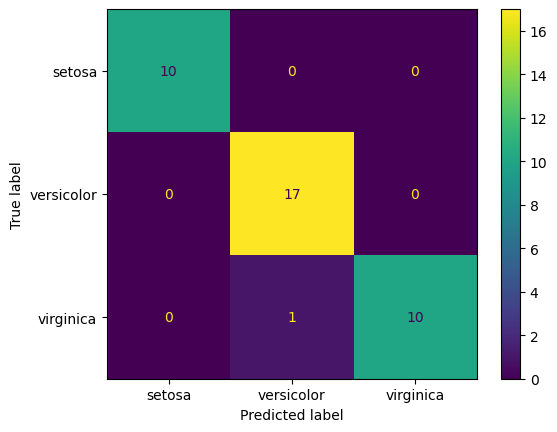

In [18]:
ConfusionMatrixDisplay.from_estimator(grid_model, scaled_X_test, y_test)

In [19]:
print(confusion_matrix(y_test, y_pred))

[[10  0  0]
 [ 0 17  0]
 [ 0  1 10]]


In [20]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.94      0.97        18
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38



In [21]:
y_pred

array(['setosa', 'setosa', 'setosa', 'virginica', 'versicolor',
       'virginica', 'versicolor', 'versicolor', 'virginica', 'setosa',
       'virginica', 'setosa', 'setosa', 'virginica', 'virginica',
       'versicolor', 'versicolor', 'versicolor', 'setosa', 'versicolor',
       'versicolor', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'virginica', 'setosa', 'setosa',
       'virginica', 'versicolor', 'virginica', 'versicolor', 'virginica',
       'versicolor', 'versicolor', 'versicolor'], dtype='<U10')